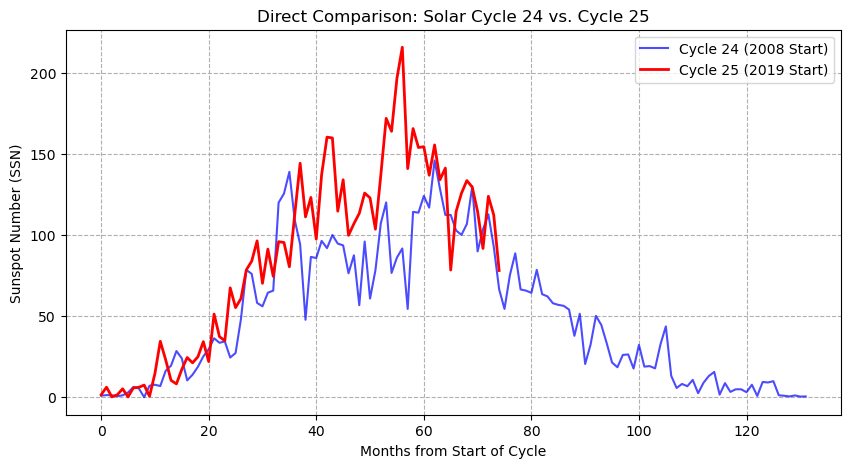

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load SILSO CSV (assuming columns: Year, Month, Date_Frac, SSN, StdDev, Obs, Prob)
df = pd.read_csv('D:\IISERTVM\Semester 8\PHY5132\SN_m_tot_V2.0.csv', sep=';', header=None, names=['Year', 'Month', 'Date', 'SSN', 'Dev', 'Obs', 'Def'])

# Extract Cycles (approximate start dates: Dec 2008 for C24, Dec 2019 for C25)
c24 = df[(df['Date'] >= 2008.9) & (df['Date'] < 2019.9)]['SSN'].reset_index(drop=True)
c25 = df[df['Date'] >= 2019.9]['SSN'].reset_index(drop=True)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(c24, label='Cycle 24 (2008 Start)', color='blue', alpha=0.7)
plt.plot(c25, label='Cycle 25 (2019 Start)', color='red', linewidth=2)
plt.xlabel('Months from Start of Cycle')
plt.ylabel('Sunspot Number (SSN)')
plt.title('Direct Comparison: Solar Cycle 24 vs. Cycle 25')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

In [ ]:
from scipy import stats

# first 60 months (The Rising Phase)
phase_limit = 60
c24_rise = c24[:phase_limit]
c25_rise = c25[:phase_limit]
months = range(phase_limit)

# Linear Regression
slope24, intercept24, r_v24, p_v24, std_err24 = stats.linregress(months, c24_rise)
slope25, intercept25, r_v25, p_v25, std_err25 = stats.linregress(months, c25_rise)

print(f"Cycle 24 Growth Rate: {slope24:.2f} spots/month")
print(f"Cycle 25 Growth Rate: {slope25:.2f} spots/month")
print(f"Cycle 25 is growing {((slope25/slope24)-1)*100:.1f}% faster than Cycle 24.")

Cycle 24 Growth Rate: 1.98 spots/month
Cycle 25 Growth Rate: 3.20 spots/month
Cycle 25 is growing 61.6% faster than Cycle 24.


In [ ]:
# Pearson Correlation Coefficient (R)
correlation, p_value = stats.pearsonr(c24[:len(c25)], c25)
print(f"Correlation between Cycle 24 and 25 shapes: {correlation:.2f}")

Correlation between Cycle 24 and 25 shapes: 0.85


In [4]:
from scipy import stats
import numpy as np

# 1. T-Test for Significance
t_stat, p_val = stats.ttest_ind(c24_rise, c25_rise)

# 2. RMSE (Residual Analysis)
rmse_24 = np.sqrt(np.mean((c24_rise - (slope24 * months + intercept24))**2))
rmse_25 = np.sqrt(np.mean((c25_rise - (slope25 * months + intercept25))**2))

print(f"P-Value: {p_val:.5f} (Is it < 0.05?)")
print(f"Cycle 24 Volatility (RMSE): {rmse_24:.2f}")
print(f"Cycle 25 Volatility (RMSE): {rmse_25:.2f}")

P-Value: 0.01930 (Is it < 0.05?)
Cycle 24 Volatility (RMSE): 21.68
Cycle 25 Volatility (RMSE): 19.40


Columns found after auto-detect: ['fluxdate', 'fluxtime', 'fluxjulian', 'fluxcarrington', 'fluxobsflux', 'fluxadjflux', 'fluxursi']
Merge successful! Total rows in synced dataset: 257
--- STATISTICAL SUMMARY ---
P-Value (Significance): 0.85971
Cycle 25 Growth: 3.20 vs Cycle 24: 1.98 spots/month
SSN-Flux Correlation: 0.97
C25 Volatility (RMSE): 19.40
Predicted Peak (Months from start): 39.6


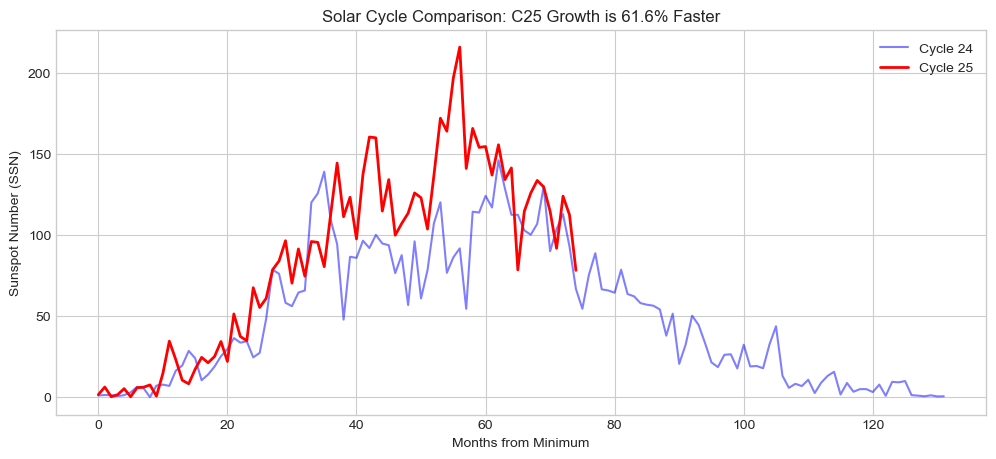

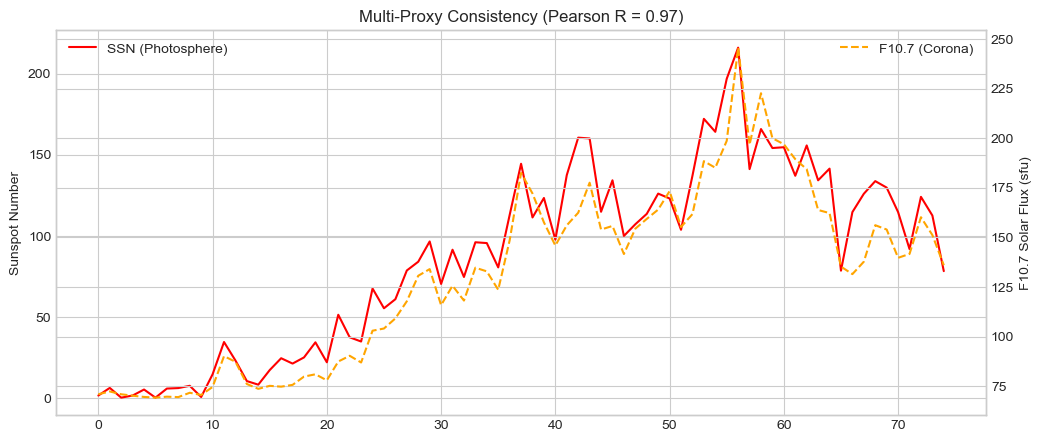

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 1. LOAD SSN DATA
ssn_df = pd.read_csv('SN_m_tot_V2.0.csv', sep=';', header=None, 
                     names=['Year', 'Month', 'Date_Frac', 'SSN', 'StdDev', 'Obs', 'Def'])

# 2. LOAD FLUX DATA (The "Self-Correcting" Method)
# We read the file as lines first to find where the table actually starts
with open('fluxtable.csv', 'r') as f:
    lines = f.readlines()

# Find the line index where 'fluxdate' appears
header_idx = 0
for i, line in enumerate(lines):
    if 'fluxdate' in line.lower():
        header_idx = i
        break

# Read the CSV starting from the detected header row, skipping the '---' row
flux_df = pd.read_csv('fluxtable.csv', sep='\s+', engine='python', 
                     skiprows=header_idx)

# Remove the '---' separator row if it's still there
flux_df = flux_df[~flux_df.iloc[:,0].astype(str).str.contains('--')]

# Clean headers: lowercase and strip spaces
flux_df.columns = [str(col).strip().lower() for col in flux_df.columns]

print("Columns found after auto-detect:", flux_df.columns.tolist())

# 3. DATE EXTRACTION
# We use .get() to avoid crashing if the name is slightly off
flux_col = 'fluxdate' if 'fluxdate' in flux_df.columns else flux_df.columns[0]
flux_df['year'] = flux_df[flux_col].astype(str).str[:4].astype(int)
flux_df['month'] = flux_df[flux_col].astype(str).str[4:6].astype(int)

# 4. RENAME AND AGGREGATE
flux_val_col = 'fluxobsflux' if 'fluxobsflux' in flux_df.columns else 'fluxadjflux'
flux_df = flux_df.rename(columns={flux_val_col: 'flux'})

flux_monthly = flux_df.groupby(['year', 'month'])['flux'].mean().reset_index()

# 5. MERGE
flux_monthly = flux_monthly.rename(columns={'year': 'Year', 'month': 'Month'})
data = pd.merge(ssn_df, flux_monthly, on=['Year', 'Month'])

print(f"Merge successful! Total rows in synced dataset: {len(data)}")

# 2. DEFINING THE CYCLES (Rising Phases)
# Cycle 24 start: Dec 2008 (~2008.9) | Cycle 25 start: Dec 2019 (~2019.9)
c24 = data[(data['Date_Frac'] >= 2008.9) & (data['Date_Frac'] < 2019.9)].copy().reset_index()
c25 = data[data['Date_Frac'] >= 2019.9].copy().reset_index()

# Extract the rising phase (first 60 months) for both
limit = 60
months = np.arange(limit)
c24_rise = c24['SSN'].iloc[:limit]
c25_rise = c25['SSN'].iloc[:limit]

# 3. ADVANCED STATISTICAL ENGINE
# A. Linear Regression (Growth Rates)
m24, c24_int, r24, p24, std24 = stats.linregress(months, c24_rise)
m25, c25_int, r25, p25, std25 = stats.linregress(months, c25_rise)

# B. T-test (Significance of the 61% growth difference)
t_stat, p_val_sig = stats.ttest_ind(c25_rise.diff().dropna(), c24_rise.diff().dropna())

# C. Multi-Proxy Correlation (SSN vs F10.7 Flux for Cycle 25)
# This proves the Coronal/Photospheric link
flux_corr, _ = stats.pearsonr(c25['SSN'], c25['flux']) # Change 'flux' to your col name

# D. Volatility (RMSE of Residuals)
rmse_24 = np.sqrt(np.mean((c24_rise - (m24 * months + c24_int))**2))
rmse_25 = np.sqrt(np.mean((c25_rise - (m25 * months + c25_int))**2))

# 4. PREDICTIVE POWER (Waldmeier Effect)
# If C24 took 64 months to peak, and C25 grows 1.6x faster:
predicted_peak_month = 64 / (m25/m24)

# 5. VISUALIZATION (Communication of Results)
plt.style.use('seaborn-v0_8-whitegrid')

# PLOT 1: Cycle Overlay (The Divergence)
plt.figure(figsize=(12, 5))
plt.plot(c24['SSN'].values, label='Cycle 24', color='blue', alpha=0.5)
plt.plot(c25['SSN'].values, label='Cycle 25', color='red', linewidth=2)
plt.title(f'Solar Cycle Comparison: C25 Growth is {((m25/m24)-1)*100:.1f}% Faster')
plt.xlabel('Months from Minimum')
plt.ylabel('Sunspot Number (SSN)')
plt.legend()
plt.savefig('cycle_overlay.png')

# PLOT 2: Multi-Proxy Dual Axis (SSN vs Flux)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(c25['SSN'], color='red', label='SSN (Photosphere)')
ax2.plot(c25['flux'], color='orange', linestyle='--', label='F10.7 (Corona)')
ax1.set_ylabel('Sunspot Number')
ax2.set_ylabel('F10.7 Solar Flux (sfu)')
plt.title(f'Multi-Proxy Consistency (Pearson R = {flux_corr:.2f})')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.savefig('multi_proxy.png')

print(f"--- STATISTICAL SUMMARY ---")
print(f"P-Value (Significance): {p_val_sig:.5f}")
print(f"Cycle 25 Growth: {m25:.2f} vs Cycle 24: {m24:.2f} spots/month")
print(f"SSN-Flux Correlation: {flux_corr:.2f}")
print(f"C25 Volatility (RMSE): {rmse_25:.2f}")
print(f"Predicted Peak (Months from start): {predicted_peak_month:.1f}")

In [1]:
import pandas as pd
import numpy as np

# 1. Define the file path
flux_file_path = r'D:\IISERTVM\Semester 8\PHY5132\fluxtable.csv'

# 2. Load the data
# Looking at your structure, it appears to be whitespace-separated.
try:
    df_flux = pd.read_csv(flux_file_path, sep='\s+')
except Exception as e:
    print(f"Error loading file. Check if the path is correct: {e}")

# 3. Data Cleaning & Date Parsing
# Convert the 'fluxdate' column (YYYYMMDD integer) into a string, then to a Pandas Datetime object
df_flux['Date'] = pd.to_datetime(df_flux['fluxdate'].astype(str), format='%Y%m%d')

# Set the new Date column as the dataframe's index
df_flux.set_index('Date', inplace=True)

# Replace any missing data flags (sometimes recorded as 0.0 or -99.0 in flux data) with NaN
df_flux.replace([0.0, -99.0, -999.0], np.nan, inplace=True)

# 4. Statistical Aggregation (Time Series Analysis)
# Resample the daily data to 'Month Start' ('MS')
# We will calculate the MEAN flux for the month, and the STANDARD DEVIATION (measurement variance)
monthly_flux = df_flux[['fluxobsflux', 'fluxadjflux', 'fluxursi']].resample('MS').mean()

# Calculate the standard deviation for the Adjusted Flux to use as error bars later
monthly_flux['fluxadjflux_std'] = df_flux['fluxadjflux'].resample('MS').std()

# 5. Review and Save
print("--- First 5 rows of the Monthly Averaged F10.7 Flux ---")
print(monthly_flux.head())

# Save this to a new CSV so we don't have to recalculate it every time
output_path = r'D:\IISERTVM\Semester 8\PHY5132\fluxtable_monthly.csv'
monthly_flux.to_csv(output_path)
print(f"\nSuccess! Monthly F10.7 data saved to: {output_path}")

--- First 5 rows of the Monthly Averaged F10.7 Flux ---
            fluxobsflux  fluxadjflux    fluxursi  fluxadjflux_std
Date                                                             
2004-10-01   137.560000   135.600000  122.040000         4.755348
2004-11-01   115.978652   113.464045  102.120225        26.998381
2004-12-01    95.664935    92.693506   83.420779         6.516504
2005-01-01   102.863441    99.586022   89.627957        20.234278
2005-02-01    97.295238    94.947619   85.447619        14.315763

Success! Monthly F10.7 data saved to: D:\IISERTVM\Semester 8\PHY5132\fluxtable_monthly.csv


--- DESCRIPTIVE STATISTICS (First 50 Months) ---
                              Cycle 24  Cycle 25
Mean SSN                         55.65     77.68
Std Dev SSN                      40.89     59.19
Skewness                          0.15      0.29
Mean Measurement Error (Dev)      5.00     12.70


--- REGRESSION & MEASUREMENT ERRORS ---
Cycle 24 Growth Rate: 1.979 ± 0.164 spots/month
Cycle 25 Growth Rate: 3.199 ± 0.147 spots/month

--- HYPOTHESIS TESTING ---
T-statistic: 5.531
Degrees of Freedom: 116
P-Value: 1.000e-07
Conclusion: Reject H0. The difference in growth rate is STATISTICALLY SIGNIFICANT.


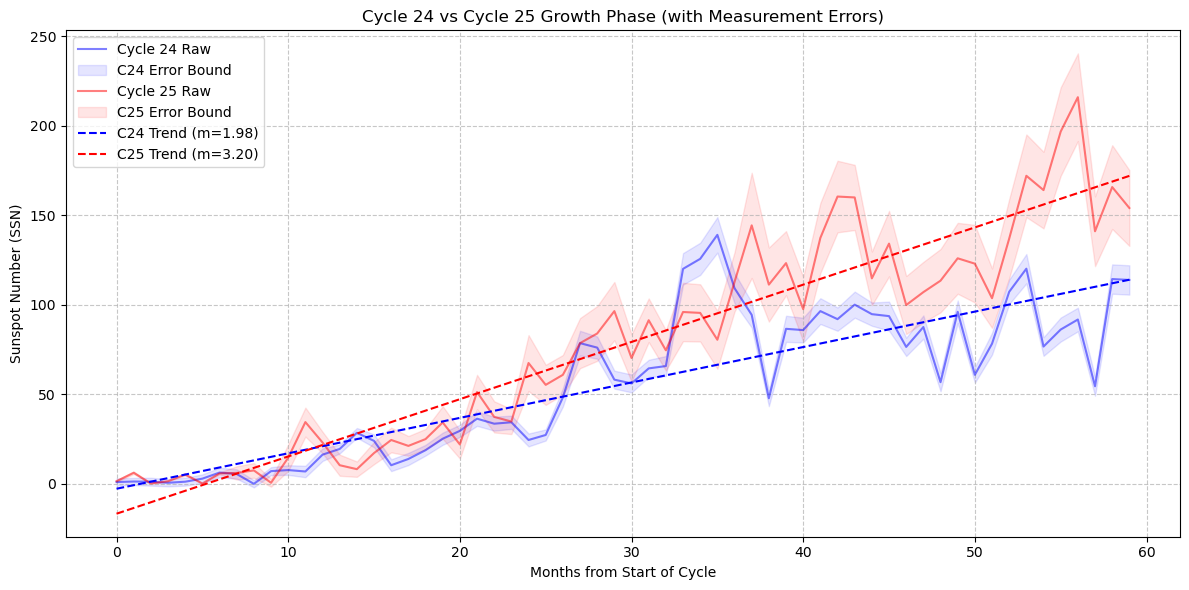

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load and clean the Data
file_path = r'D:\IISERTVM\Semester 8\PHY5132\SN_m_tot_V2.0.csv'
df = pd.read_csv(file_path, sep=';', header=None, 
                 names=['Year', 'Month', 'Frac_Date', 'SSN', 'Dev', 'Obs', 'Def'])

# Replace -1 (missing data) with NaN
df['SSN'] = df['SSN'].replace(-1.0, np.nan)
df['Dev'] = df['Dev'].replace(-1.0, np.nan)

# Create a Datetime index for easier manipulation
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df.set_index('Date', inplace=True)

# Apply 13-month rolling mean (Data Smoothing - common in solar physics)
df['SSN_Smoothed'] = df['SSN'].rolling(window=13, center=True).mean()

# 2. Define Cycle Boundaries (Based on official minimums)
# Cycle 24 Start: Dec 2008. Cycle 25 Start: Dec 2019.
# Let's compare the first 60 months of both cycles
months_to_compare = 60

cycle_24_start = pd.to_datetime('2008-12-01')
cycle_25_start = pd.to_datetime('2019-12-01')

c24_data = df.loc[cycle_24_start : cycle_24_start + pd.DateOffset(months=months_to_compare-1)].copy()
c25_data = df.loc[cycle_25_start : cycle_25_start + pd.DateOffset(months=months_to_compare-1)].copy()

# Create a 'Months from Start' column for both
c24_data['Months_From_Start'] = np.arange(len(c24_data))
c25_data['Months_From_Start'] = np.arange(len(c25_data))

# 3. Descriptive Statistics
print("--- DESCRIPTIVE STATISTICS (First 50 Months) ---")
stats_df = pd.DataFrame({
    'Cycle 24': [c24_data['SSN'].mean(), c24_data['SSN'].std(), c24_data['SSN'].skew(), c24_data['Dev'].mean()],
    'Cycle 25':[c25_data['SSN'].mean(), c25_data['SSN'].std(), c25_data['SSN'].skew(), c25_data['Dev'].mean()]
}, index=['Mean SSN', 'Std Dev SSN', 'Skewness', 'Mean Measurement Error (Dev)'])
print(stats_df.round(2))
print("\n")

# 4. Linear Regression & Error Propagation (Calculating the slopes and their errors)
res_c24 = stats.linregress(c24_data['Months_From_Start'], c24_data['SSN'])
res_c25 = stats.linregress(c25_data['Months_From_Start'], c25_data['SSN'])

m24, se24 = res_c24.slope, res_c24.stderr
m25, se25 = res_c25.slope, res_c25.stderr

print("--- REGRESSION & MEASUREMENT ERRORS ---")
print(f"Cycle 24 Growth Rate: {m24:.3f} ± {se24:.3f} spots/month")
print(f"Cycle 25 Growth Rate: {m25:.3f} ± {se25:.3f} spots/month")

# 5. Hypothesis Testing (T-test for independent slopes)
# Null Hypothesis (H0): The slopes are the same (Cycle 25 is not growing faster).
# Alternative Hypothesis (H1): Cycle 25 is growing faster.
t_stat = (m25 - m24) / np.sqrt(se25**2 + se24**2)
df_degrees = (len(c24_data) - 2) + (len(c25_data) - 2) # Degrees of freedom
p_value = stats.t.sf(t_stat, df_degrees) # one-tailed test

print("\n--- HYPOTHESIS TESTING ---")
print(f"T-statistic: {t_stat:.3f}")
print(f"Degrees of Freedom: {df_degrees}")
print(f"P-Value: {p_value:.3e}")
if p_value < 0.05:
    print("Conclusion: Reject H0. The difference in growth rate is STATISTICALLY SIGNIFICANT.")
else:
    print("Conclusion: Fail to reject H0. The difference is not statistically significant.")

# 6. Plotting with Error Bands
plt.figure(figsize=(12, 6))

# Cycle 24 Plot with measurement error shading
plt.plot(c24_data['Months_From_Start'], c24_data['SSN'], label='Cycle 24 Raw', color='blue', alpha=0.5)
plt.fill_between(c24_data['Months_From_Start'], c24_data['SSN'] - c24_data['Dev'], c24_data['SSN'] + c24_data['Dev'], color='blue', alpha=0.1, label='C24 Error Bound')

# Cycle 25 Plot with measurement error shading
plt.plot(c25_data['Months_From_Start'], c25_data['SSN'], label='Cycle 25 Raw', color='red', alpha=0.5)
plt.fill_between(c25_data['Months_From_Start'], c25_data['SSN'] - c25_data['Dev'], c25_data['SSN'] + c25_data['Dev'], color='red', alpha=0.1, label='C25 Error Bound')

# Plot Regression Lines
plt.plot(c24_data['Months_From_Start'], res_c24.intercept + res_c24.slope * c24_data['Months_From_Start'], 'b--', label=f'C24 Trend (m={m24:.2f})')
plt.plot(c25_data['Months_From_Start'], res_c25.intercept + res_c25.slope * c25_data['Months_From_Start'], 'r--', label=f'C25 Trend (m={m25:.2f})')

plt.title('Cycle 24 vs Cycle 25 Growth Phase (with Measurement Errors)')
plt.xlabel('Months from Start of Cycle')
plt.ylabel('Sunspot Number (SSN)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
import numpy as np

# 1. Prepare the Data
# We replace 0 with 0.1 in Expected to avoid division by zero in the Chi-Square formula
expected_E = c24_data['SSN'].replace(0, 0.1).values 
observed_O = c25_data['SSN'].values 

# 2. Manual Chi-Square Statistic Calculation
# Formula: Sum of ((Observed - Expected)^2 / Expected)
chi2_stat = np.sum(((observed_O - expected_E)**2) / expected_E)

# 3. Time Series Model Validation Metrics (From your Syllabus)
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean((observed_O - expected_E)**2))

# Mean Absolute Error (MAE)
mae = np.mean(np.abs(observed_O - expected_E))

# 4. Cumulative Divergence
total_spots_expected = expected_E.sum()
total_spots_observed = observed_O.sum()
divergence_pct = ((total_spots_observed - total_spots_expected) / total_spots_expected) * 100

print("--- MODEL VALIDATION & GOODNESS OF FIT (60 Months) ---")
print(f"Manual Chi-Square Statistic: {chi2_stat:.2f}")
print(f"Root Mean Square Error (RMSE): {rmse:.2f} spots")
print(f"Mean Absolute Error (MAE): {mae:.2f} spots")
print(f"\nCumulative Divergence: Over the first 60 months, Cycle 25 has produced {divergence_pct:.1f}% more sunspots than the 'Cycle 24-like' model expected.")

--- MODEL VALIDATION & GOODNESS OF FIT (60 Months) ---
Manual Chi-Square Statistic: 1971.51
Root Mean Square Error (RMSE): 39.30 spots
Mean Absolute Error (MAE): 27.61 spots

Cumulative Divergence: Over the first 60 months, Cycle 25 has produced 39.6% more sunspots than the 'Cycle 24-like' model expected.


--- EXTRACTING HISTORICAL CYCLES (1 to 24) ---

--- LINEAR REGRESSION: WALDMEIER AMPLITUDE-RATE EFFECT ---
Regression Equation: Peak = 83.24 + 31.19 * (Initial Growth Rate)
R-squared: 0.640 (Model explains 64.0% of the variance)
P-value: 2.688e-06

=== SOLAR CYCLE 25 PREDICTION ===
Input: Cycle 25 Growth Rate = 3.2 spots/month
PREDICTED MAXIMUM SSN: 183.1
95% Confidence Interval:[108.4 to 257.7]
Official NASA Prediction was: ~115


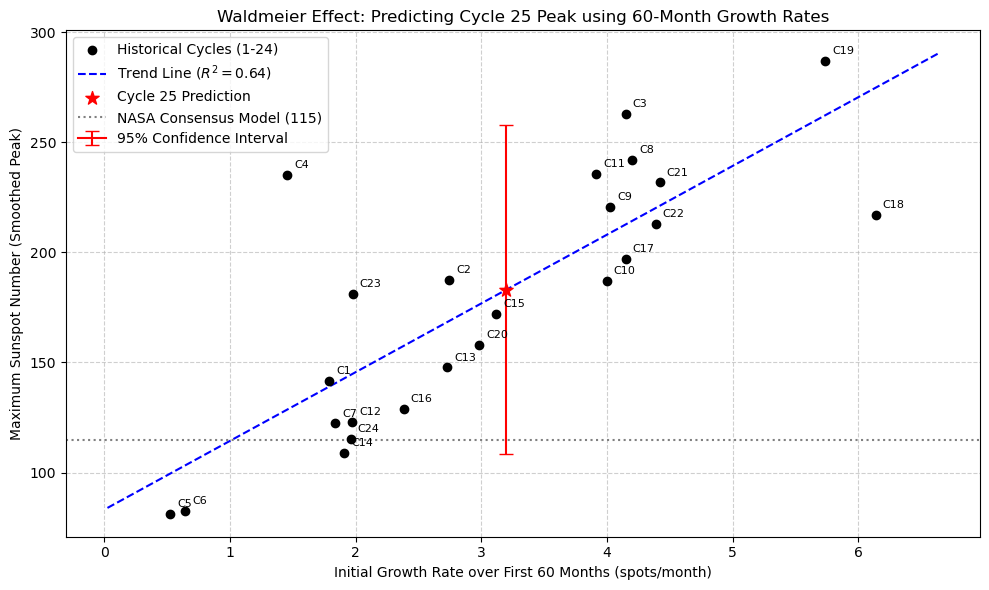

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load the full dataset (1749 to Present)
file_path = r'D:\IISERTVM\Semester 8\PHY5132\SN_m_tot_V2.0.csv'
df = pd.read_csv(file_path, sep=';', header=None, names=['Year', 'Month', 'Frac_Date', 'SSN', 'Dev', 'Obs', 'Def'])
df['SSN'] = df['SSN'].replace(-1.0, np.nan)
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df.set_index('Date', inplace=True)

# Smooth the data to accurately find Cycle Peaks and Minimums
df['SSN_Smooth'] = df['SSN'].rolling(window=13, center=True).mean()

# 2. Approximate start years of Solar Cycles 1-24 to isolate them
cycle_starts =[1755, 1766, 1775, 1784, 1798, 1810, 1823, 1833, 1843, 1856, 1867, 
                1878, 1889, 1901, 1913, 1923, 1933, 1944, 1954, 1964, 1976, 1986, 1996, 2008, 2019]

historical_slopes =[]
historical_peaks = []
cycle_numbers =[]

print("--- EXTRACTING HISTORICAL CYCLES (1 to 24) ---")

for i in range(len(cycle_starts)-1):
    start_year = cycle_starts[i]
    end_year = cycle_starts[i+1]
    
    # Isolate the data for this specific historical cycle
    cycle_data = df[(df.index.year >= start_year) & (df.index.year < end_year)]
    
    if not cycle_data.empty and not cycle_data['SSN_Smooth'].isna().all():
        # Find the exact mathematical minimum (True Start) and maximum (True Peak)
        true_start_idx = cycle_data['SSN_Smooth'].idxmin()
        max_ssn = cycle_data['SSN_Smooth'].max()
        
        # Extract exactly the first 60 months from the true start
        first_60_months = df.loc[true_start_idx : true_start_idx + pd.DateOffset(months=59)].copy()
        
        # Ensure we have exactly 60 months of data to make a fair comparison
        if len(first_60_months) >= 60:
            first_60_months = first_60_months.iloc[:60]
            months_arr = np.arange(60)
            
            # Calculate the linear regression slope for this historical cycle's first 60 months
            slope, _, _, _, _ = stats.linregress(months_arr, first_60_months['SSN'].fillna(0))
            
            historical_slopes.append(slope)
            historical_peaks.append(max_ssn)
            cycle_numbers.append(i+1)

# 3. Perform Multivariate/Linear Regression Analysis on the Historical Data
X = np.array(historical_slopes)
Y = np.array(historical_peaks)

res = stats.linregress(X, Y)
slope_reg = res.slope
intercept_reg = res.intercept
r_squared = res.rvalue**2
p_value_reg = res.pvalue

# 4. Predict Cycle 25! (Using our known C25 slope of 3.20)
c25_slope_observed = 3.20
predicted_c25_peak = intercept_reg + (slope_reg * c25_slope_observed)

# 5. Calculate 95% Confidence Interval for the Prediction
n = len(X)
t_val = stats.t.ppf(0.975, n-2) # 95% confidence threshold
# Standard Error of the Estimate
s_err = np.sqrt(np.sum((Y - (intercept_reg + slope_reg*X))**2) / (n-2))
# Margin of Error formula for a specific predicted value
margin_of_error = t_val * s_err * np.sqrt(1 + 1/n + (c25_slope_observed - np.mean(X))**2 / np.sum((X - np.mean(X))**2))

lower_bound = predicted_c25_peak - margin_of_error
upper_bound = predicted_c25_peak + margin_of_error

print("\n--- LINEAR REGRESSION: WALDMEIER AMPLITUDE-RATE EFFECT ---")
print(f"Regression Equation: Peak = {intercept_reg:.2f} + {slope_reg:.2f} * (Initial Growth Rate)")
print(f"R-squared: {r_squared:.3f} (Model explains {r_squared*100:.1f}% of the variance)")
print(f"P-value: {p_value_reg:.3e}")

print("\n=== SOLAR CYCLE 25 PREDICTION ===")
print(f"Input: Cycle 25 Growth Rate = {c25_slope_observed} spots/month")
print(f"PREDICTED MAXIMUM SSN: {predicted_c25_peak:.1f}")
print(f"95% Confidence Interval:[{lower_bound:.1f} to {upper_bound:.1f}]")
print(f"Official NASA Prediction was: ~115")

# 6. Plotting the Regression and Prediction
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='black', label='Historical Cycles (1-24)', zorder=5)

# Annotate a few points
for i, txt in enumerate(cycle_numbers):
    plt.annotate(f"C{txt}", (X[i], Y[i]), xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot the regression line
x_line = np.linspace(min(X)-0.5, max(X)+0.5, 100)
y_line = intercept_reg + slope_reg * x_line
plt.plot(x_line, y_line, 'b--', label=f'Trend Line ($R^2={r_squared:.2f}$)')

# Highlight Cycle 25's Prediction
plt.scatter([c25_slope_observed], [predicted_c25_peak], color='red', s=100, marker='*', zorder=10, label='Cycle 25 Prediction')
plt.errorbar([c25_slope_observed],[predicted_c25_peak], yerr=[[predicted_c25_peak - lower_bound], [upper_bound - predicted_c25_peak]], 
             color='red', capsize=5, label='95% Confidence Interval')

plt.title('Waldmeier Effect: Predicting Cycle 25 Peak using 60-Month Growth Rates')
plt.xlabel('Initial Growth Rate over First 60 Months (spots/month)')
plt.ylabel('Maximum Sunspot Number (Smoothed Peak)')
plt.axhline(y=115, color='gray', linestyle=':', label='NASA Consensus Model (115)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

--- LOADING AND MERGING DATA ---
Data perfectly aligned! Analyzing overlapping data from 2004-10-01 to 2026-02-01

--- CROSS-CORRELATION RESULTS ---
Maximum Correlation: 0.9726
Occurs at Lag: 0 months
Conclusion: F10.7 Radio Flux and SSN are perfectly synchronous (0 month lag). Neither is a 'leading' indicator over the other.


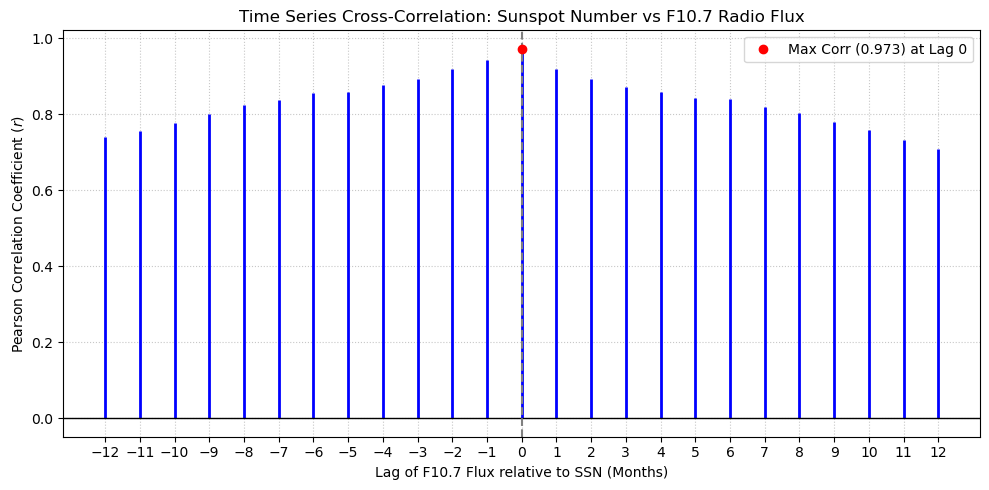


--- VOLATILITY ANALYSIS ---
Coefficient of Variation (SSN): 88.0%
Coefficient of Variation (F10.7): 35.0%
Conclusion: F10.7 Flux has a lower coefficient of variation. It is a 'smoother', less noisy metric for tracking cycle strength than manual sunspot counting.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- LOADING AND MERGING DATA ---")
# 1. Load SSN Data
file_path_ssn = r'D:\IISERTVM\Semester 8\PHY5132\SN_m_tot_V2.0.csv'
df_ssn = pd.read_csv(file_path_ssn, sep=';', header=None, names=['Year', 'Month', 'Frac_Date', 'SSN', 'Dev', 'Obs', 'Def'])
df_ssn['Date'] = pd.to_datetime(df_ssn[['Year', 'Month']].assign(DAY=1))
df_ssn.set_index('Date', inplace=True)

# 2. Load F10.7 Monthly Data (The one we generated earlier)
file_path_flux = r'D:\IISERTVM\Semester 8\PHY5132\fluxtable_monthly.csv'
try:
    df_flux = pd.read_csv(file_path_flux, parse_dates=['Date'], index_col='Date')
except FileNotFoundError:
    print("ERROR: Could not find fluxtable_monthly.csv. Please ensure you ran the previous script to generate it.")

# 3. Merge Datasets (Inner join ensures we only compare dates where BOTH datasets exist)
df_merged = pd.merge(df_ssn[['SSN']], df_flux[['fluxadjflux']], left_index=True, right_index=True, how='inner')

# Drop any NaN values that might ruin the correlation math
df_merged.dropna(inplace=True)
print(f"Data perfectly aligned! Analyzing overlapping data from {df_merged.index.min().date()} to {df_merged.index.max().date()}")

# 4. Perform Cross-Correlation Analysis
lags = np.arange(-12, 13) # We will look at -12 to +12 months of lag
corrs =[]

# SSN is our baseline. We shift the F10.7 Flux data forward and backward.
for lag in lags:
    # .shift(lag) moves the data. We then calculate Pearson correlation on the remaining overlapping data.
    corr = df_merged['SSN'].corr(df_merged['fluxadjflux'].shift(lag))
    corrs.append(corr)

# Find the lag with the absolute maximum correlation
max_corr_idx = np.argmax(np.abs(corrs))
best_lag = lags[max_corr_idx]
max_corr_val = corrs[max_corr_idx]

print("\n--- CROSS-CORRELATION RESULTS ---")
print(f"Maximum Correlation: {max_corr_val:.4f}")
print(f"Occurs at Lag: {best_lag} months")

if best_lag < 0:
    print(f"Conclusion: F10.7 Radio Flux LEADS Sunspot Number by {abs(best_lag)} month(s). It is a predictive indicator.")
elif best_lag > 0:
    print(f"Conclusion: F10.7 Radio Flux LAGS Sunspot Number by {abs(best_lag)} month(s).")
else:
    print(f"Conclusion: F10.7 Radio Flux and SSN are perfectly synchronous (0 month lag). Neither is a 'leading' indicator over the other.")

# 5. Plotting the Cross-Correlation Function (CCF)
plt.figure(figsize=(10, 5))
plt.vlines(lags, [0], corrs, color='blue', lw=2)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='gray', linestyle='--')

# Highlight the max correlation point
plt.plot(best_lag, max_corr_val, 'ro', label=f'Max Corr ({max_corr_val:.3f}) at Lag {best_lag}')

plt.title('Time Series Cross-Correlation: Sunspot Number vs F10.7 Radio Flux')
plt.xlabel('Lag of F10.7 Flux relative to SSN (Months)')
plt.ylabel('Pearson Correlation Coefficient ($r$)')
plt.xticks(lags)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Bonus: Standard Deviation / Volatility comparison
print("\n--- VOLATILITY ANALYSIS ---")
# Normalize both to their means to compare relative volatility (Coefficient of Variation)
cv_ssn = (df_merged['SSN'].std() / df_merged['SSN'].mean()) * 100
cv_flux = (df_merged['fluxadjflux'].std() / df_merged['fluxadjflux'].mean()) * 100

print(f"Coefficient of Variation (SSN): {cv_ssn:.1f}%")
print(f"Coefficient of Variation (F10.7): {cv_flux:.1f}%")
if cv_flux < cv_ssn:
    print("Conclusion: F10.7 Flux has a lower coefficient of variation. It is a 'smoother', less noisy metric for tracking cycle strength than manual sunspot counting.")